In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib
import os

print("All libraries imported successfully.")

All libraries imported successfully.


In [10]:
import pandas as pd
import numpy as np

print("Python is working")

Python is working


In [11]:
df = pd.read_csv("../data/train_values.csv")
labels = pd.read_csv("../data/train_labels.csv")

df = df.merge(labels, on="building_id")

print(df.shape)
print(df.head())

(260601, 40)
   building_id  geo_level_1_id  geo_level_2_id  geo_level_3_id  \
0       802906               6             487           12198   
1        28830               8             900            2812   
2        94947              21             363            8973   
3       590882              22             418           10694   
4       201944              11             131            1488   

   count_floors_pre_eq  age  area_percentage  height_percentage  \
0                    2   30                6                  5   
1                    2   10                8                  7   
2                    2   10                5                  5   
3                    2   10                6                  5   
4                    3   30                8                  9   

  land_surface_condition foundation_type  ... has_secondary_use_hotel  \
0                      t               r  ...                       0   
1                      o               r 

In [12]:
X = df.drop("damage_grade", axis=1)
y = df["damage_grade"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (260601, 39)
y shape: (260601,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)

Training data: (208480, 39)
Validation data: (52121, 39)


In [14]:
numeric_features = X.select_dtypes(include=["number"]).columns
categorical_features = X.select_dtypes(include=["object", "string"]).columns

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features.tolist())

Number of numerical features: 31
Number of categorical features: 8

Categorical features:
['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [16]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Evaluation metrics imported.")

Evaluation metrics imported.


In [20]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "feature_selection",
            SelectKBest(
                score_func=f_classif,
                k=20
            )
        ),

        (
            "scaler",
            StandardScaler()
        ),

        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=7,
                n_jobs=-1
            )
        )
    ]
)

print("KNN model created.")

KNN model created.


In [21]:
print("Training KNN...")
print("This may take some time because the dataset is large.")

knn_model.fit(X_train, y_train)

print("KNN training completed.")

Training KNN...
This may take some time because the dataset is large.
KNN training completed.


In [22]:
print("Predicting using KNN...")

knn_pred = knn_model.predict(X_val)

print("KNN prediction completed.")

Predicting using KNN...
KNN prediction completed.


In [23]:
knn_accuracy = accuracy_score(y_val, knn_pred)

knn_f1 = f1_score(
    y_val,
    knn_pred,
    average="micro"
)

print("========== KNN RESULTS ==========")
print("Accuracy:", knn_accuracy)
print("Micro F1:", knn_f1)

========== KNN RESULTS ==========
Accuracy: 0.6456514648606128
Micro F1: 0.6456514648606128


In [24]:
nn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),

        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ],
    remainder="drop"
)

print("Neural Network preprocessing created.")

Neural Network preprocessing created.


In [25]:
nn_model = Pipeline(
    steps=[
        (
            "preprocessor",
            nn_preprocessor
        ),

        (
            "classifier",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                max_iter=30,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=5
            )
        )
    ]
)

print("Neural Network model created.")

Neural Network model created.


In [26]:
print("Training Neural Network...")
print("This may take some time.")

nn_model.fit(
    X_train,
    y_train
)

print("Neural Network training completed.")

Training Neural Network...
This may take some time.
Neural Network training completed.


c:\Users\Prarthana Acharya\earthquake-damage-ml\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [30]:
nn_pred = nn_model.predict(X_val)

print("Neural Network prediction completed.")

Neural Network prediction completed.


In [31]:
nn_accuracy = accuracy_score(
    y_val,
    nn_pred
)

nn_f1 = f1_score(
    y_val,
    nn_pred,
    average="micro"
)

print("========== NEURAL NETWORK RESULTS ==========")
print("Accuracy:", nn_accuracy)
print("Micro F1:", nn_f1)

========== NEURAL NETWORK RESULTS ==========
Accuracy: 0.6639742138485447
Micro F1: 0.6639742138485447


In [36]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest model created.")

Random Forest model created.


In [40]:
print("Training Random Forest...")
print("This may take some time.")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Training Random Forest...
This may take some time.
Random Forest training completed.


In [41]:
rf_pred = rf_model.predict(X_val)

print("Random Forest prediction completed.")

Random Forest prediction completed.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

rf_tuned = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training tuned Random Forest...")

rf_tuned.fit(X_train, y_train)

print("Training completed.")

rf_tuned_pred = rf_tuned.predict(X_val)

rf_tuned_accuracy = accuracy_score(y_val, rf_tuned_pred)
rf_tuned_f1 = f1_score(y_val, rf_tuned_pred, average="micro")

print("Random Forest Accuracy:", rf_tuned_accuracy)
print("Random Forest Micro F1:", rf_tuned_f1)

Training tuned Random Forest...
Training completed.
Random Forest Accuracy: 0.7214558431342453
Random Forest Micro F1: 0.7214558431342453


In [63]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "Neural Network",
        "Random Forest"
    ],

    "Accuracy": [
        knn_accuracy,
        nn_accuracy,
        rf_tuned_accuracy
    ],

    "Micro F1": [
        knn_f1,
        nn_f1,
        rf_tuned_f1
    ]
})

results = results.sort_values(
    by="Micro F1",
    ascending=False
).reset_index(drop=True)

print(results)

            Model  Accuracy  Micro F1
0   Random Forest  0.721456  0.721456
1  Neural Network  0.663974  0.663974
2             KNN  0.645651  0.645651


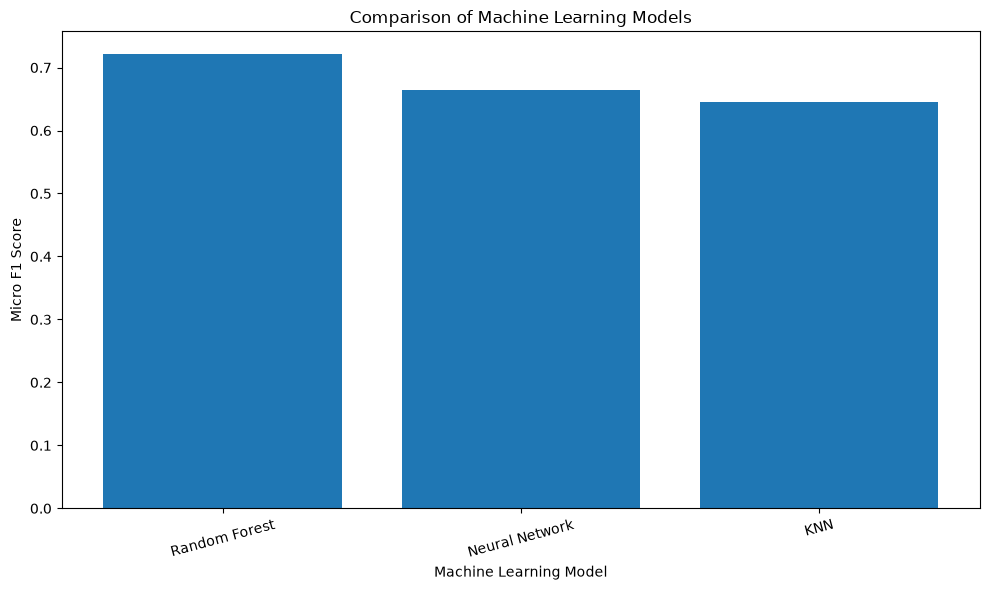

In [64]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["Micro F1"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Micro F1 Score")
plt.title("Comparison of Machine Learning Models")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

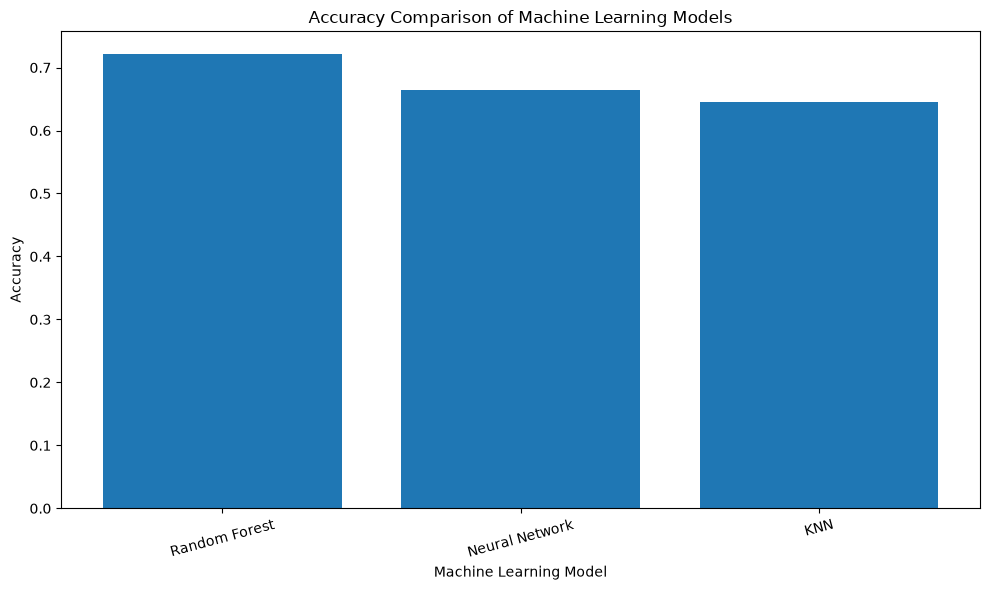

In [65]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Machine Learning Models")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [66]:
best_model_name = results.loc[0, "Model"]

print("Best Model:", best_model_name)
print("Best Micro F1:", results.loc[0, "Micro F1"])
print("Best Accuracy:", results.loc[0, "Accuracy"])

Best Model: Random Forest
Best Micro F1: 0.7214558431342453
Best Accuracy: 0.7214558431342453


In [67]:
print("========== RANDOM FOREST CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        rf_pred
    )
)

========== RANDOM FOREST CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           1       0.66      0.46      0.54      5025
           2       0.72      0.84      0.78     29652
           3       0.74      0.58      0.65     17444

    accuracy                           0.72     52121
   macro avg       0.70      0.63      0.66     52121
weighted avg       0.72      0.72      0.71     52121



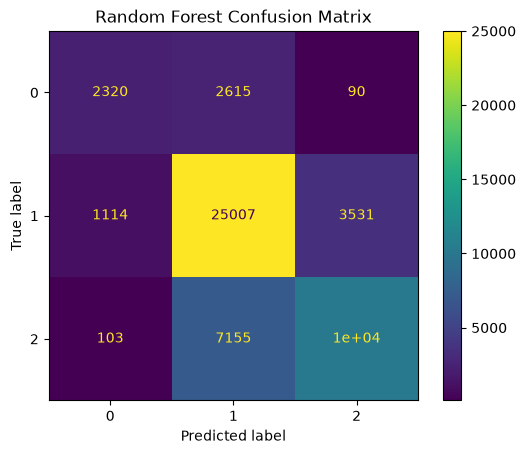

In [68]:
cm = confusion_matrix(
    y_val,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [69]:
fitted_preprocessor = rf_model.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

rf_classifier = rf_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

                                              Feature  Importance
38                             remainder__building_id    0.148500
39                          remainder__geo_level_1_id    0.124626
41                          remainder__geo_level_3_id    0.122719
40                          remainder__geo_level_2_id    0.116450
43                                     remainder__age    0.090101
44                         remainder__area_percentage    0.084248
45                       remainder__height_percentage    0.047584
57                          remainder__count_families    0.020701
42                     remainder__count_floors_pre_eq    0.014918
5                      categorical__foundation_type_r    0.014559
47     remainder__has_superstructure_mud_mortar_stone    0.012593
13                   categorical__ground_floor_type_v    0.010718
52               remainder__has_superstructure_timber    0.010454
2               categorical__land_surface_condition_t    0.008556
11        

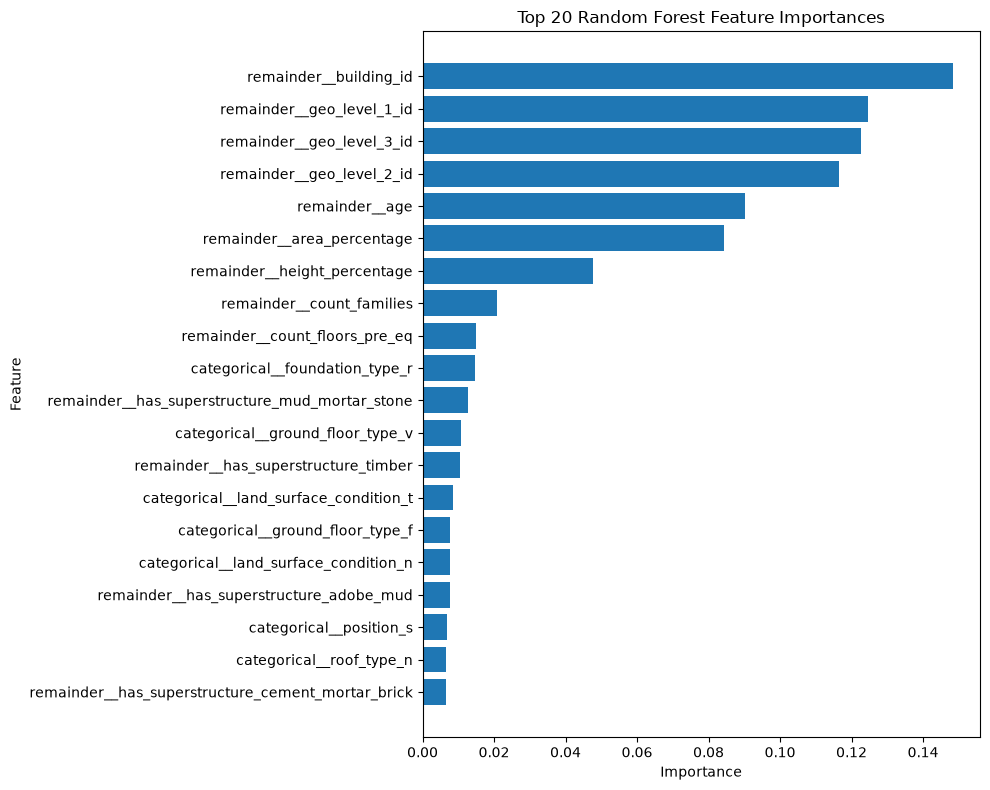

In [70]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [71]:
if best_model_name == "Random Forest":
    best_model = rf_model

elif best_model_name == "Neural Network":
    best_model = nn_model

elif best_model_name == "KNN":
    best_model = knn_model

else:
    raise ValueError("Unknown model")

In [72]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("Best model saved successfully.")
print("Location: ../models/best_model.pkl")

Best model saved successfully.
Location: ../models/best_model.pkl


In [73]:
model_path = "../models/best_model.pkl"

print("Model exists:", os.path.exists(model_path))

Model exists: True
